In [ ]:
from google.colab import files
uploaded = files.upload()

Saving sales_06_FY2020-21 copy.csv to sales_06_FY2020-21 copy.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML & Prophet
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
from prophet import Prophet
import joblib

plt.style.use('seaborn-v0_8')

# Load Data
data = pd.read_csv("/content/sales_06_FY2020-21 copy.csv")
print("Shape:", data.shape)
print("Columns:", data.columns.tolist())
data.head()

Shape: (286392, 36)
Columns: ['order_id', 'order_date', 'status', 'item_id', 'sku', 'qty_ordered', 'price', 'value', 'discount_amount', 'total', 'category', 'payment_method', 'bi_st', 'cust_id', 'year', 'month', 'ref_num', 'Name Prefix', 'First Name', 'Middle Initial', 'Last Name', 'Gender', 'age', 'full_name', 'E Mail', 'Customer Since', 'SSN', 'Phone No. ', 'Place Name', 'County', 'City', 'State', 'Zip', 'Region', 'User Name', 'Discount_Percent']


,order_id,order_date,status,item_id,sku,qty_ordered,price,value,discount_amount,total,...,SSN,Phone No.,Place Name,County,City,State,Zip,Region,User Name,Discount_Percent
0,100354678,2020-10-01,received,574772.0,oasis_Oasis-064-36,21.0,89.9,1798.0,0.0,1798.0,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
1,100354678,2020-10-01,received,574774.0,Fantastic_FT-48,11.0,19.0,190.0,0.0,190.0,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
2,100354680,2020-10-01,complete,574777.0,mdeal_DMC-610-8,9.0,149.9,1199.2,0.0,1199.2,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
3,100354680,2020-10-01,complete,574779.0,oasis_Oasis-061-36,9.0,79.9,639.2,0.0,639.2,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0
4,100367357,2020-11-13,received,595185.0,MEFNAR59C38B6CA08CD,2.0,99.9,99.9,0.0,99.9,...,627-31-5251,405-959-1129,Vinson,Harmon,Vinson,OK,73571,South,jwtitus,0.0


In [ ]:
# Convert date
data['order_date'] = pd.to_datetime(data['order_date'], errors='coerce')

# Drop rows with missing critical values
data = data.dropna(subset=['order_date', 'User Name', 'category', 'price', 'qty_ordered'])

# Revenue Calculation
data['revenue'] = data['qty_ordered'] * data['price']

# Additional Features
data['discount_rate'] = data['discount_amount'] / data['value'].replace(0, 1)
data['is_discounted'] = (data['discount_amount'] > 0).astype(int)
data['month'] = data['order_date'].dt.month
data['dayofweek'] = data['order_date'].dt.dayofweek
data['price_per_unit'] = data['price']

print("Cleaned Shape:", data.shape)
data.info()

Cleaned Shape: (286392, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286392 entries, 0 to 286391
Data columns (total 41 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   order_id          286392 non-null  object        
 1   order_date        286392 non-null  datetime64[ns]
 2   status            286392 non-null  object        
 3   item_id           286392 non-null  float64       
 4   sku               286392 non-null  object        
 5   qty_ordered       286392 non-null  float64       
 6   price             286392 non-null  float64       
 7   value             286392 non-null  float64       
 8   discount_amount   286392 non-null  float64       
 9   total             286392 non-null  float64       
 10  category          286392 non-null  object        
 11  payment_method    286392 non-null  object        
 12  bi_st             286392 non-null  object        
 13  cust_id           286392 non-nu

In [ ]:
latest_date = data['order_date'].max()

rfm = data.groupby('User Name').agg({
    'order_date': lambda x: (latest_date - x.max()).days,
    'order_id': 'count',
    'revenue': 'sum'
}).rename(columns={
    'order_date': 'Recency',
    'order_id': 'Frequency',
    'revenue': 'Monetary'
})

# Outlier Removal
rfm = rfm[rfm['Monetary'] < rfm['Monetary'].quantile(0.99)]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

segment_map = {0: 'Loyal', 1: 'VIP', 2: 'Lost', 3: 'Regular'}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

print(rfm['Segment'].value_counts())
rfm.head()

Segment
Regular    32798
Lost       26912
Loyal       3319
VIP          336
Name: count, dtype: int64


,Recency,Frequency,Monetary,Cluster,Segment
User Name,,,,,
aaabell,110,6,23832.9,3,Regular
aaacree,201,1,189.8,3,Regular
aaagin,277,2,3836.7,2,Lost
aaallie,0,1,1099.8,3,Regular
aaapperson,275,4,28088.7,0,Loyal


In [ ]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,161.250377,12.070202,43310.991873
1,90.029762,77.925595,31637.299381
2,281.142762,2.889603,3012.548871
3,127.202939,3.257668,3132.229379


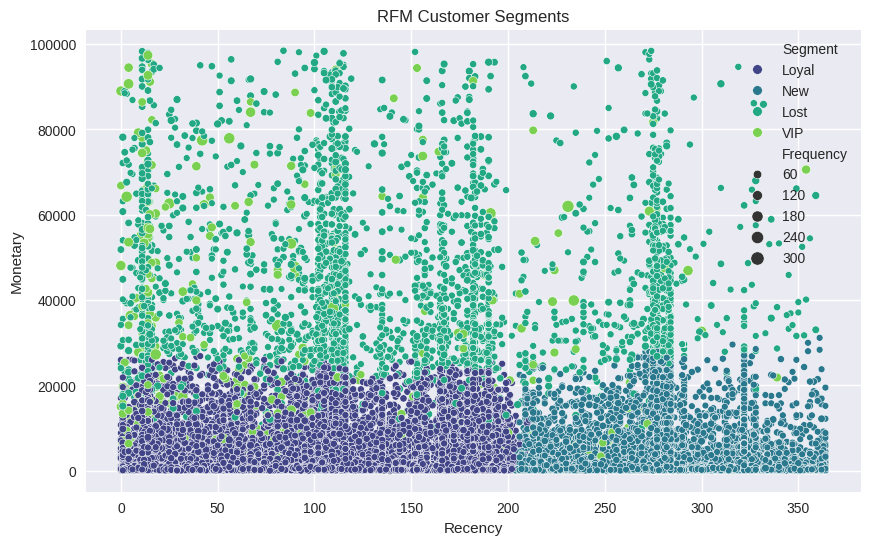

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm.reset_index(), x='Recency', y='Monetary',
                hue='Segment', size='Frequency', palette='viridis')
plt.title('RFM Customer Segments')
plt.show()

INFO:prophet:n_changepoints greater than number of observations. Using 8.


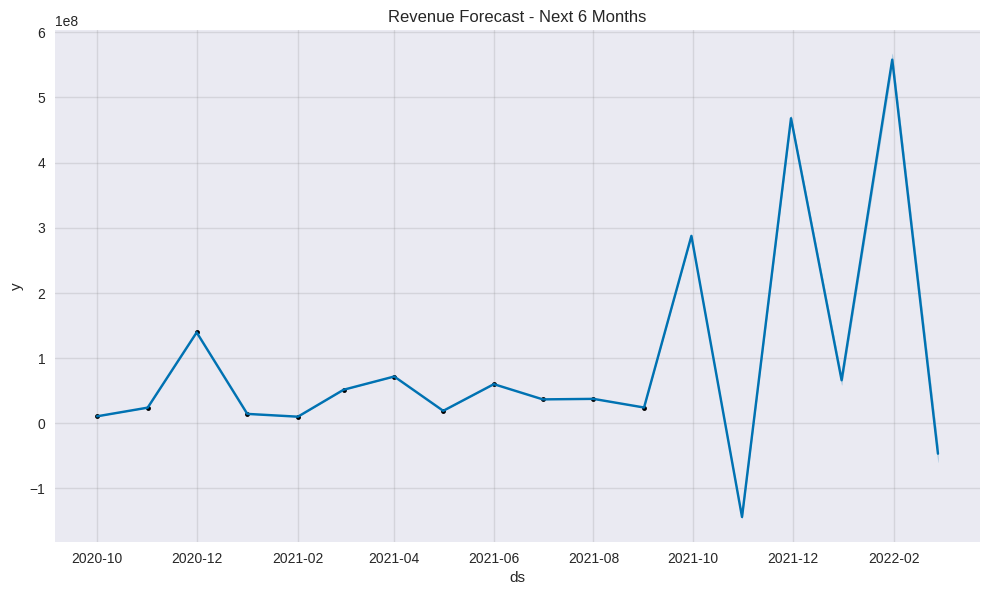

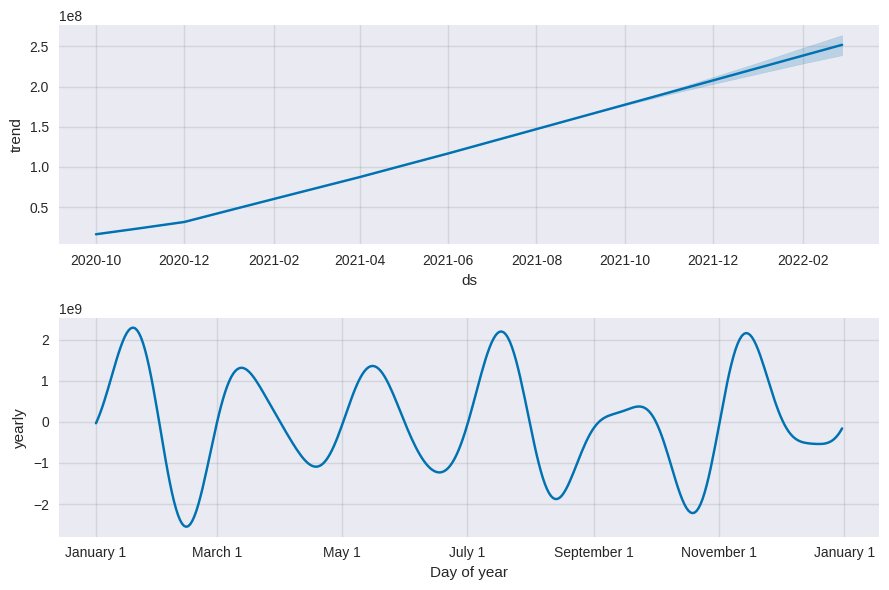

In [ ]:
monthly = data.groupby(data['order_date'].dt.to_period('M'))['revenue'].sum().reset_index()
monthly['ds'] = monthly['order_date'].dt.to_timestamp()
monthly = monthly.rename(columns={'revenue': 'y'}).drop(columns=['order_date'])

model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(monthly)

future = model.make_future_dataframe(periods=6, freq='M')
forecast = model.predict(future)

model.plot(forecast)
plt.title('Revenue Forecast - Next 6 Months')
plt.show()

model.plot_components(forecast)
plt.show()

In [ ]:
pred_data = data.copy()

# Strong Feature Engineering
pred_data['revenue'] = pred_data['qty_ordered'] * pred_data['price']
pred_data['discount_rate'] = pred_data['discount_amount'] / pred_data['value'].replace(0, 1)
pred_data['is_discounted'] = (pred_data['discount_amount'] > 0).astype(int)
pred_data['month'] = pred_data['order_date'].dt.month
pred_data['dayofweek'] = pred_data['order_date'].dt.dayofweek

# SKU Features
pred_data['sku'] = pred_data['sku'].astype(str)
pred_data['sku_prefix'] = pred_data['sku'].str[:6]
pred_data['sku_prefix2'] = pred_data['sku'].str[:4]
pred_data['sku_contains_me'] = pred_data['sku'].str.contains('MEF|ME', case=False, na=False).astype(int)
pred_data['sku_contains_mat'] = pred_data['sku'].str.contains('MAT', case=False, na=False).astype(int)
pred_data['sku_contains_wof'] = pred_data['sku'].str.contains('WOF', case=False, na=False).astype(int)
pred_data['sku_contains_app'] = pred_data['sku'].str.contains('APP', case=False, na=False).astype(int)

# Price & Quantity Bins
pred_data['price_range'] = pd.qcut(pred_data['price'], q=10, duplicates='drop', labels=False)
pred_data['qty_range'] = pd.qcut(pred_data['qty_ordered'], q=8, duplicates='drop', labels=False)

# Encoding
le = LabelEncoder()
pred_data['category_encoded'] = le.fit_transform(pred_data['category'])

# Final Features List
features = ['price', 'qty_ordered', 'value', 'discount_amount', 'revenue', 'discount_rate',
            'is_discounted', 'month', 'dayofweek', 'price_range', 'qty_range',
            'sku_contains_me', 'sku_contains_mat', 'sku_contains_wof', 'sku_contains_app']

X = pred_data[features]
y = pred_data['category_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# XGBoost Final
xgb_model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=16,
    learning_rate=0.06,
    subsample=0.85,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1,
    tree_method='hist'
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print(" FINAL XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Feature Importance
importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
print("\n Top Features:\n", importances.head(15))

 FINAL XGBoost Accuracy: 0.8767960334503047

Classification Report:
                     precision    recall  f1-score   support

        Appliances       1.00      1.00      1.00      6607
 Beauty & Grooming       0.56      0.59      0.58      3580
             Books       0.55      0.55      0.55       163
         Computing       0.70      0.67      0.69      1622
     Entertainment       0.90      0.91      0.91      3470
   Health & Sports       0.57      0.55      0.56      1684
     Home & Living       0.55      0.57      0.56      2798
       Kids & Baby       0.42      0.37      0.39      1298
     Men's Fashion       0.99      0.99      0.99      8143
 Mobiles & Tablets       1.00      1.00      1.00     12352
            Others       0.97      0.99      0.98      5222
School & Education       0.40      0.28      0.33       218
           Soghaat       0.59      0.58      0.59      1450
        Superstore       0.72      0.71      0.72      3005
   Women's Fashion       0.99 

In [ ]:
import joblib
from prophet.serialize import model_to_json

# Save KMeans
joblib.dump(kmeans, 'kmeans_rfm.pkl')

# Save XGBoost
joblib.dump(xgb_model, 'product_category_xgb.pkl')

# Save Prophet Model
with open('prophet_revenue_model.json', 'w') as f:
    f.write(model_to_json(model))

print(" All models saved successfully")
print("   • kmeans_rfm.pkl")
print("   • product_category_xgb.pkl")
print("   • prophet_revenue_model.json")

 All models saved successfully
   • kmeans_rfm.pkl
   • product_category_xgb.pkl
   • prophet_revenue_model.json
